**Task 3: Heart Disease Prediction**

**Objective:**

 Build a model to predict whether a person is at risk of heart disease based on their health data.

**Dataset:**

 Heart Disease UCI Dataset (available on Kaggle)

In [69]:
# Task 3: Heart Disease Prediction
# Dataset: Heart Disease UCI (from Kaggle)

# Step 1: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc, RocCurveDisplay

In [70]:
# Step 2: Load dataset
df = pd.read_csv('/content/Heart Disease UCI.csv')

In [71]:
# Step 3: Initial data inspection
print("Dataset Shape:", df.shape)
print("Column Names:", df.columns.tolist())
print(df.head())
print(df.info())
print(df.describe())

Dataset Shape: (297, 14)
Column Names: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'condition']
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   69    1   0       160   234    1        2      131      0      0.1      1   
1   69    0   0       140   239    0        0      151      0      1.8      0   
2   66    0   0       150   226    0        0      114      0      2.6      2   
3   65    1   0       138   282    1        2      174      0      1.4      1   
4   64    1   0       110   211    0        2      144      1      1.8      1   

   ca  thal  condition  
0   1     0          0  
1   2     0          0  
2   0     0          0  
3   1     0          1  
4   0     0          0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 297 entries, 0 to 296
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age     

In [72]:
# Step 4: Check for missing values
missing_values = df.isnull().sum()
print("Missing Values:\n", missing_values)

if missing_values.sum() == 0:
    print("No missing values found. Proceeding to EDA.")

Missing Values:
 age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalach      0
exang        0
oldpeak      0
slope        0
ca           0
thal         0
condition    0
dtype: int64
No missing values found. Proceeding to EDA.


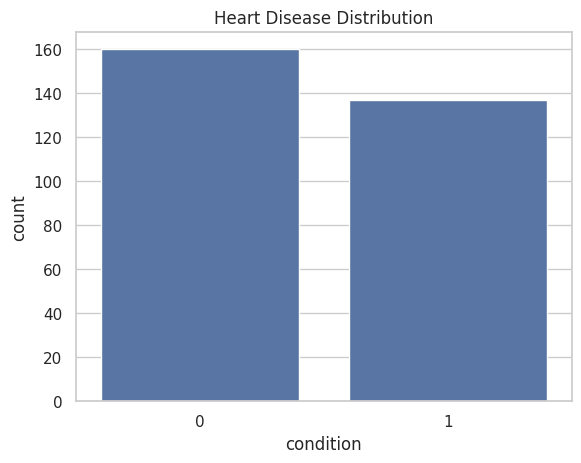

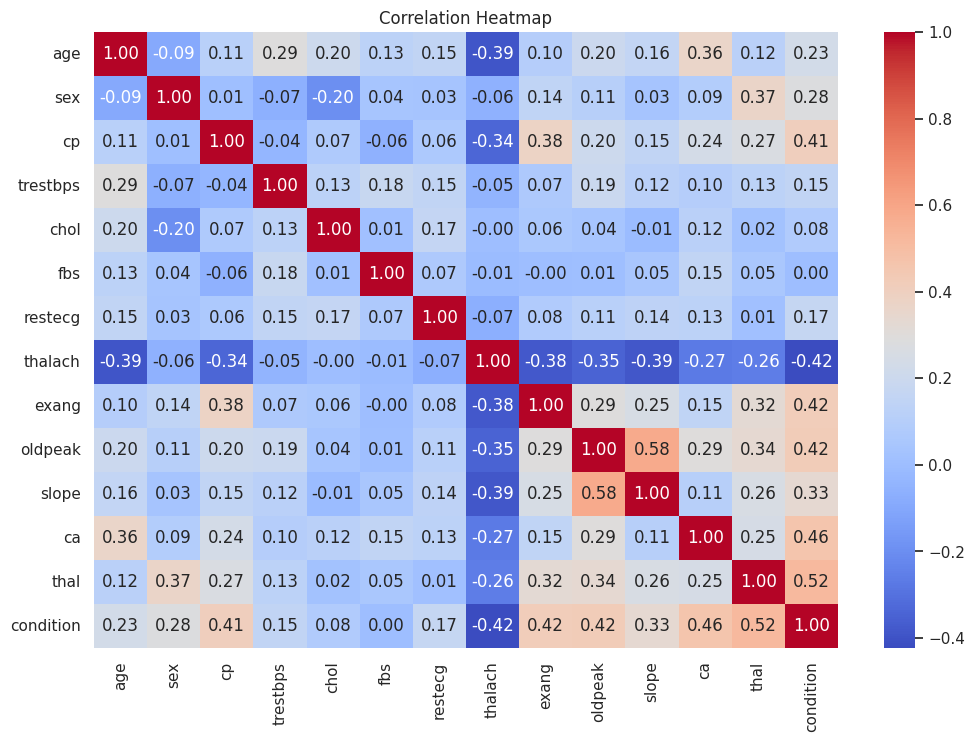

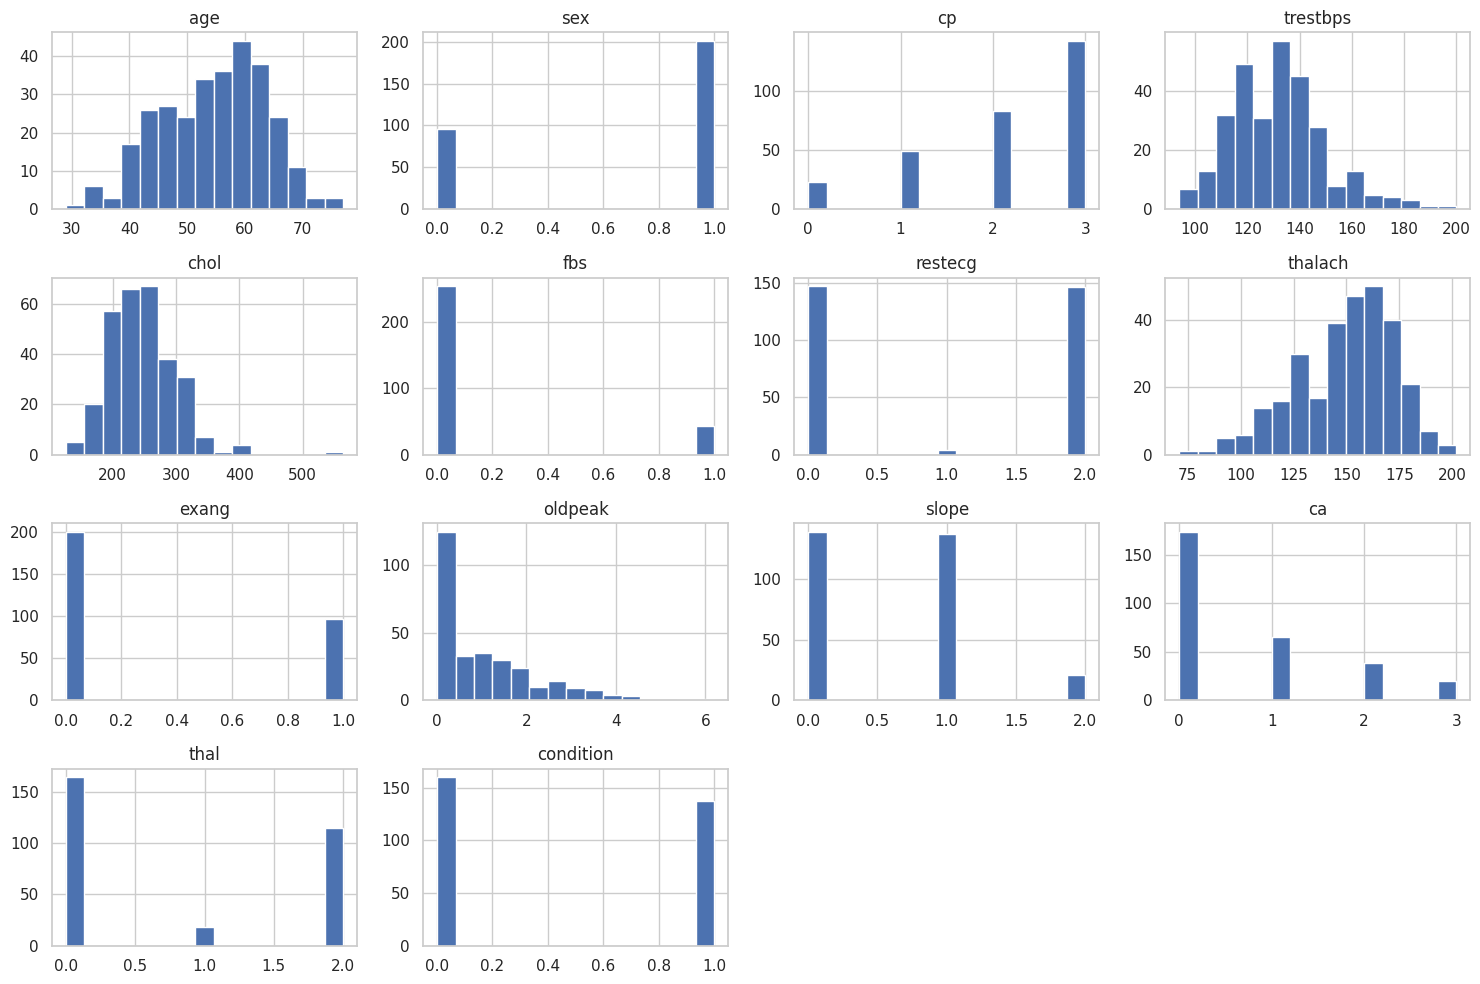

In [73]:
# Step 5: Exploratory Data Analysis (EDA)

# Target distribution
sns.countplot(x='condition', data=df)
plt.title("Heart Disease Distribution")
plt.show()

# Correlation heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# Histograms for numeric features
df.hist(bins=15, figsize=(15,10))
plt.tight_layout()
plt.show()

In [74]:
# Step 6: Feature selection and preprocessing
X = df.drop('condition', axis=1)  # features
y = df['condition']                # target

# Standardize numeric features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [75]:
# Step 7: Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

In [76]:
# Step 8: Train Classification Models

# Option 1: Logistic Regression
logreg = LogisticRegression(random_state=42)
logreg.fit(X_train, y_train)
y_pred_lr = logreg.predict(X_test)
y_prob_lr = logreg.predict_proba(X_test)[:,1]

# Option 2: Decision Tree Classifier
dtree = DecisionTreeClassifier(random_state=42)
dtree.fit(X_train, y_train)
y_pred_dt = dtree.predict(X_test)
y_prob_dt = dtree.predict_proba(X_test)[:,1]

Logistic Regression Accuracy: 0.9167


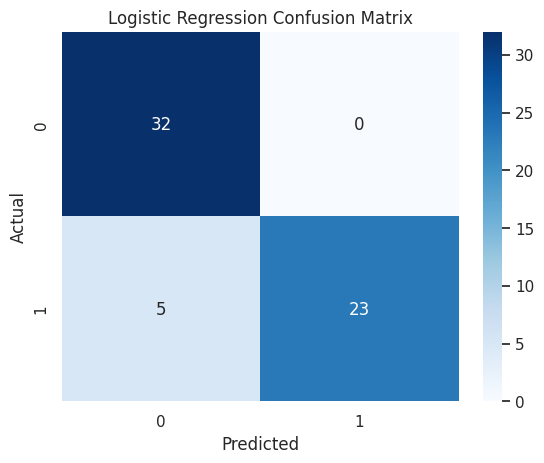

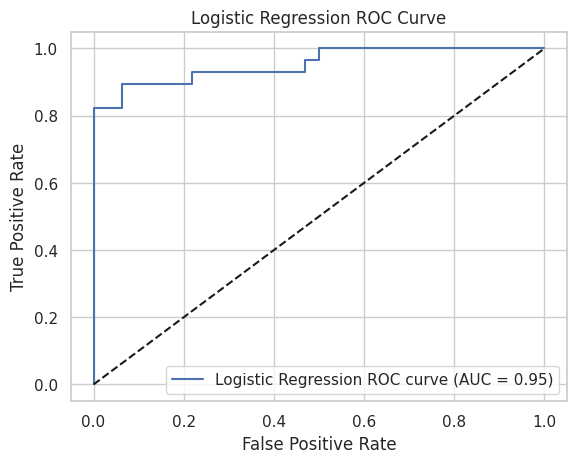

Decision Tree Accuracy: 0.8000


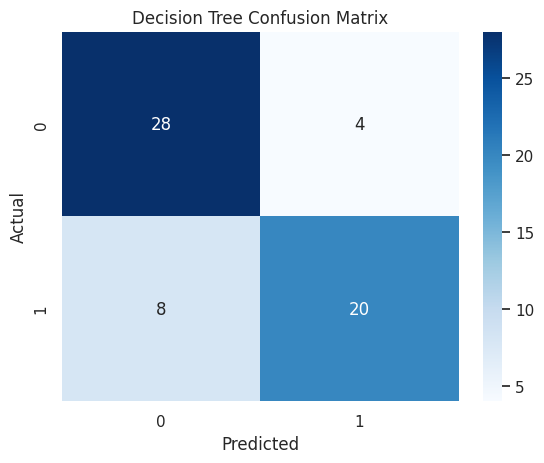

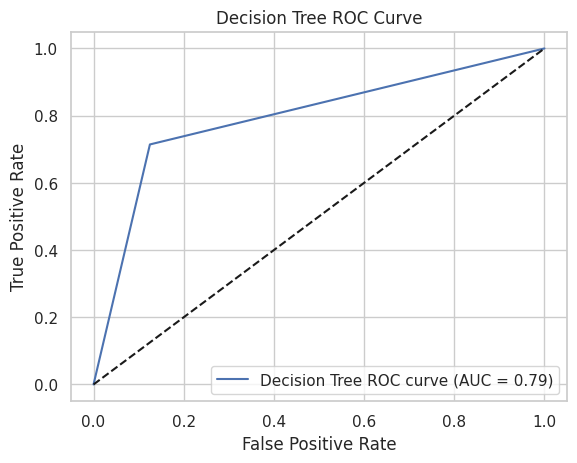

In [77]:
# Step 9: Model Evaluation

def evaluate_model(y_true, y_pred, y_prob, model_name="Model"):
    # Accuracy
    acc = accuracy_score(y_true, y_pred)
    print(f"{model_name} Accuracy: {acc:.4f}")

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{model_name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # ROC Curve
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.figure()
    plt.plot(fpr, tpr, label=f"{model_name} ROC curve (AUC = {roc_auc:.2f})")
    plt.plot([0,1], [0,1], 'k--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{model_name} ROC Curve")
    plt.legend(loc="lower right")
    plt.show()

# Evaluate Logistic Regression
evaluate_model(y_test, y_pred_lr, y_prob_lr, "Logistic Regression")

# Evaluate Decision Tree
evaluate_model(y_test, y_pred_dt, y_prob_dt, "Decision Tree")

In [78]:
# Step 10: Feature Importance
# Logistic Regression coefficients
feature_importance_lr = pd.DataFrame({
    'Feature': df.drop('condition', axis=1).columns,
    'Coefficient': logreg.coef_[0]
}).sort_values(by='Coefficient', key=abs, ascending=False)
print("Logistic Regression Feature Importance:")
print(feature_importance_lr)

# Decision Tree feature importance
feature_importance_dt = pd.DataFrame({
    'Feature': df.drop('condition', axis=1).columns,
    'Importance': dtree.feature_importances_
}).sort_values(by='Importance', ascending=False)
print("\nDecision Tree Feature Importance:")
print(feature_importance_dt)

Logistic Regression Feature Importance:
     Feature  Coefficient
11        ca     1.012992
12      thal     0.577100
7    thalach    -0.484857
2         cp     0.473178
8      exang     0.446504
9    oldpeak     0.406621
1        sex     0.385400
3   trestbps     0.305206
5        fbs    -0.279030
10     slope     0.247405
4       chol     0.160574
6    restecg     0.131546
0        age    -0.096512

Decision Tree Feature Importance:
     Feature  Importance
2         cp    0.296026
9    oldpeak    0.162500
10     slope    0.081394
0        age    0.076946
1        sex    0.075676
11        ca    0.075506
7    thalach    0.072684
3   trestbps    0.071311
4       chol    0.060969
12      thal    0.026989
8      exang    0.000000
5        fbs    0.000000
6    restecg    0.000000


**Insights:**
1. Key features influencing heart disease:
   - Logistic Regression: features with highest absolute coefficients.
   - Decision Tree: features with highest importance.
2. Logistic Regression captures linear relationships between features and heart disease risk.
3. Decision Tree captures non-linear interactions and feature importance in prediction.
4. Both models provide a baseline; further tuning can improve performance.